In [8]:
import torch 
from tqdm import tqdm
import warnings
from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
import glob
from collections import OrderedDict  
from ReportPretraining import ReportClassification
from src.layers.transformer.lightcurve import LightCurveTransformer
from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY

In [9]:
import h5py
with h5py.File('/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5','r') as f:
    print(f.keys())


<KeysViewHDF5 ['SNID', 'align_training_0', 'align_training_1', 'align_training_2', 'align_training_3', 'align_training_4', 'align_validation_0', 'align_validation_1', 'align_validation_2', 'align_validation_3', 'align_validation_4', 'data', 'data-var', 'feats_0008', 'feats_0016', 'feats_0032', 'feats_0064', 'feats_0128', 'feats_0256', 'feats_0512', 'feats_1024', 'feats_2048', 'finetuning_training_0', 'finetuning_training_0_sn_only', 'finetuning_training_1', 'finetuning_training_2', 'finetuning_training_3', 'finetuning_training_4', 'finetuning_validation_0', 'finetuning_validation_0_sn_only', 'finetuning_validation_1', 'finetuning_validation_2', 'finetuning_validation_3', 'finetuning_validation_4', 'labels', 'labels_sn_only', 'mask', 'mask_alert', 'mask_detection', 'norm_feat_col', 'old_training_0', 'old_training_1', 'old_training_2', 'old_training_3', 'old_training_4', 'old_validation_0', 'old_validation_1', 'old_validation_2', 'old_validation_3', 'old_validation_4', 'target_classes', 

In [10]:
len(ELASTICC_TAXONOMY)
print(ELASTICC_TAXONOMY())

{'CART': 0, 'SNIax': 1, '91bg': 2, 'SNIa': 3, 'SNIbc': 4, 'SNII': 5, 'SLSN': 6, 'PISN': 7, 'TDE': 8, 'ILOT': 9, 'SNKN': 10, 'M-dwarf Flare': 11, 'Microlens': 12, 'Dwarf Novae': 13, 'AGN': 14, 'DeltaScuti': 15, 'RRL': 16, 'Cepheid': 17, 'EB': 18}


['/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_elasticc/classifier_ckpt.ckpt']
using checkpoint /home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_elasticc/classifier_ckpt.ckpt
LC


100%|██████████| 477/477 [00:17<00:00, 27.60it/s]


               precision    recall  f1-score   support

         CART     0.0542    0.1569    0.0806       204
        SNIax     0.0912    0.3931    0.1480       781
         91bg     0.2280    0.6262    0.3343       816
         SNIa     0.4747    0.5048    0.4893      3508
        SNIbc     0.4975    0.3168    0.3871      4766
         SNII     0.7474    0.4284    0.5446      8592
         SLSN     0.6675    0.7505    0.7066      1840
         PISN     0.8361    0.9033    0.8684      1830
          TDE     0.7250    0.8021    0.7616      1900
         ILOT     0.3077    0.4188    0.3548       191
         SNKN     0.2905    0.5417    0.3782        96
M-dwarf Flare     0.3409    0.4688    0.3947        32
    Microlens     0.7980    0.8289    0.8132       491
  Dwarf Novae     0.7269    0.7674    0.7466       215
          AGN     0.9723    0.9641    0.9682      2146
   DeltaScuti     0.9227    0.9382    0.9304       534
          RRL     0.8954    0.9252    0.9101       361
      Cep

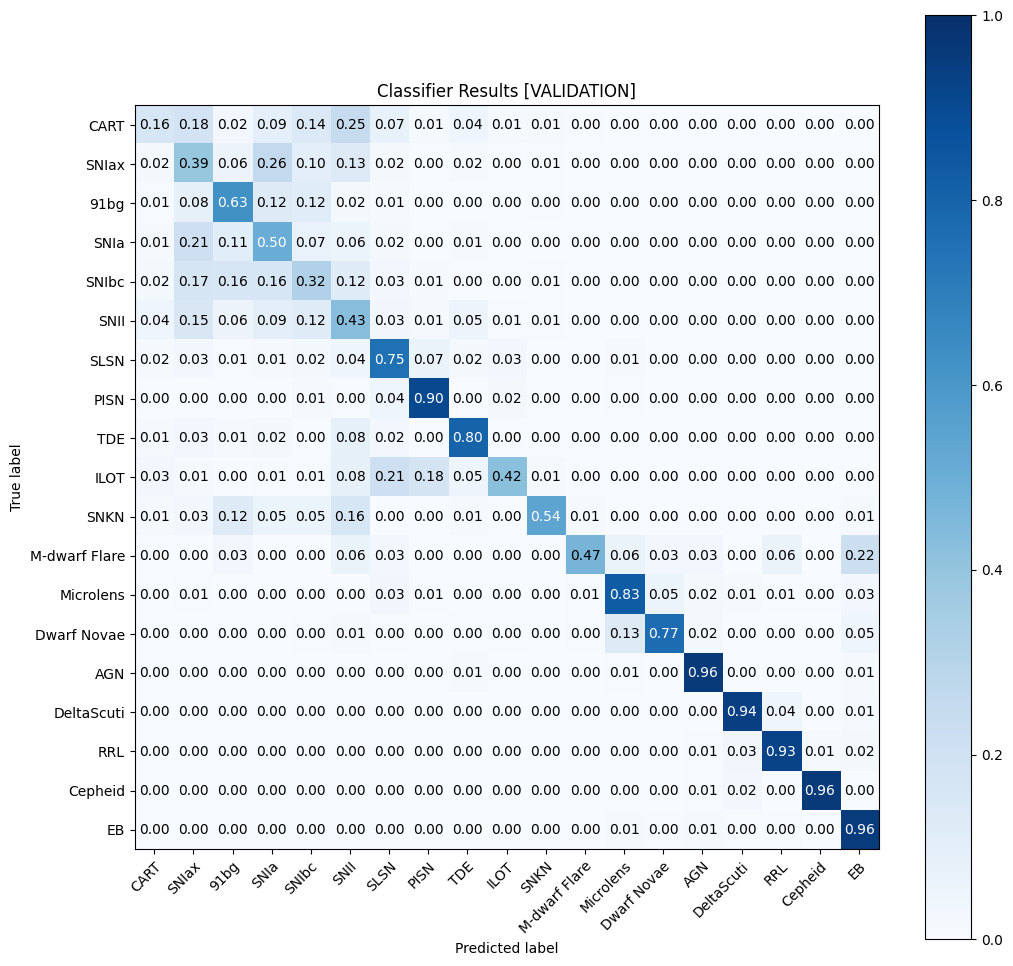

In [11]:
test = ReportClassification(
    path_to_training_dir='/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_elasticc/',
    #path_to_dataset= 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5',
    path_to_dataset= '/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5',
    model_class = LightCurveTransformer,
    custom_parse_key_str= '',
    model_type = 'lc',
    taxonomy = ELASTICC_TAXONOMY,
    device = 'cuda:2',
    seed = 0,
    figsize = (10,10),
    batch_size=64,
    umap_args={"n_neighbors": 15, "min_dist": 0.05, "metric": "euclidean"},
    marker_size = 6)
#test.classification_report()
fig,test_cm_1 = test.classification_report('validation')

['/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_elasticc_ELASTICC_one_brach_BN_v11_256/classifier_ckpt.ckpt']
using checkpoint /home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_elasticc_ELASTICC_one_brach_BN_v11_256/classifier_ckpt.ckpt
LC


100%|██████████| 477/477 [00:17<00:00, 27.26it/s]


               precision    recall  f1-score   support

         CART     0.0375    0.1078    0.0557       204
        SNIax     0.0878    0.2138    0.1245       781
         91bg     0.2680    0.5527    0.3609       816
         SNIa     0.4443    0.5733    0.5006      3508
        SNIbc     0.4750    0.3624    0.4111      4766
         SNII     0.7561    0.4380    0.5546      8592
         SLSN     0.6514    0.7321    0.6894      1840
         PISN     0.8030    0.9087    0.8526      1830
          TDE     0.6224    0.8526    0.7195      1900
         ILOT     0.3038    0.3770    0.3364       191
         SNKN     0.2727    0.5625    0.3673        96
M-dwarf Flare     0.3429    0.3750    0.3582        32
    Microlens     0.8182    0.8065    0.8123       491
  Dwarf Novae     0.7277    0.7581    0.7426       215
          AGN     0.9583    0.9753    0.9667      2146
   DeltaScuti     0.9252    0.9270    0.9261       534
          RRL     0.8918    0.9363    0.9135       361
      Cep

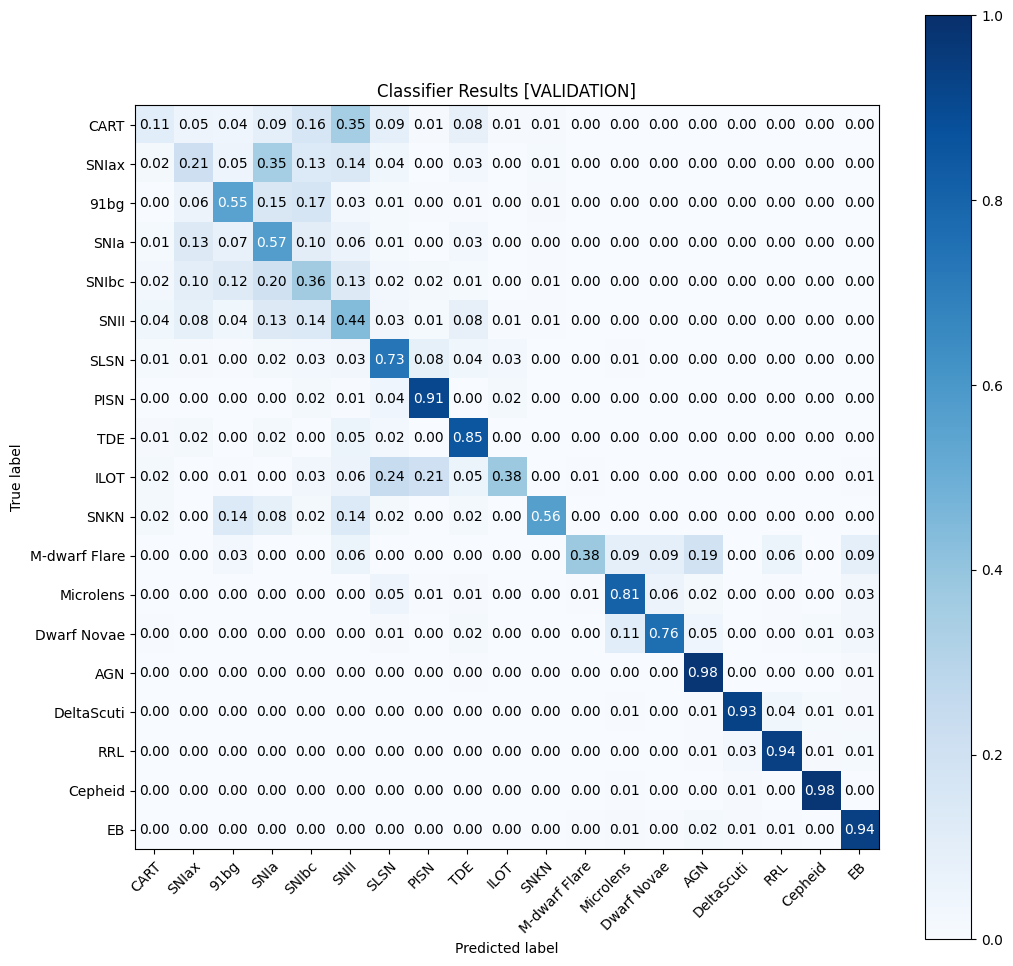

In [12]:
test = ReportClassification(
    path_to_training_dir='/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_elasticc_ELASTICC_one_brach_BN_v11_256/',
    #path_to_dataset= 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5',
    path_to_dataset= '/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5',
    model_class = LightCurveTransformer,
    custom_parse_key_str= '',
    model_type = 'lc',
    taxonomy = ELASTICC_TAXONOMY,
    device = 'cuda:2',
    seed = 0,
    figsize = (10,10),
    batch_size=64,
    umap_args={"n_neighbors": 15, "min_dist": 0.05, "metric": "euclidean"},
    marker_size = 6)
fig,test_cm_2 = test.classification_report('validation')

LC


  0%|          | 0/297 [00:00<?, ?it/s]

100%|██████████| 297/297 [00:11<00:00, 26.99it/s]


               precision    recall  f1-score   support

         CART     0.3929    0.1210    0.1850      1000
        SNIax     0.3238    0.2380    0.2744      1000
         91bg     0.5574    0.5490    0.5531      1000
         SNIa     0.3505    0.5520    0.4287      1000
        SNIbc     0.3027    0.3620    0.3297      1000
         SNII     0.2995    0.4280    0.3524      1000
         SLSN     0.5783    0.7350    0.6473      1000
         PISN     0.7103    0.9120    0.7986      1000
          TDE     0.6982    0.8490    0.7662      1000
         ILOT     0.8170    0.3930    0.5307      1000
         SNKN     0.8974    0.5770    0.7024      1000
M-dwarf Flare     0.9118    0.4030    0.5589      1000
    Microlens     0.7658    0.8010    0.7830      1000
  Dwarf Novae     0.8462    0.7980    0.8214      1000
          AGN     0.8107    0.9680    0.8824      1000
   DeltaScuti     0.8979    0.8970    0.8974      1000
          RRL     0.9269    0.9380    0.9324      1000
      Cep

(<Figure size 1200x1200 with 2 Axes>,
 <Axes: title={'center': 'Classifier Results [TEST]'}, xlabel='Predicted label', ylabel='True label'>)

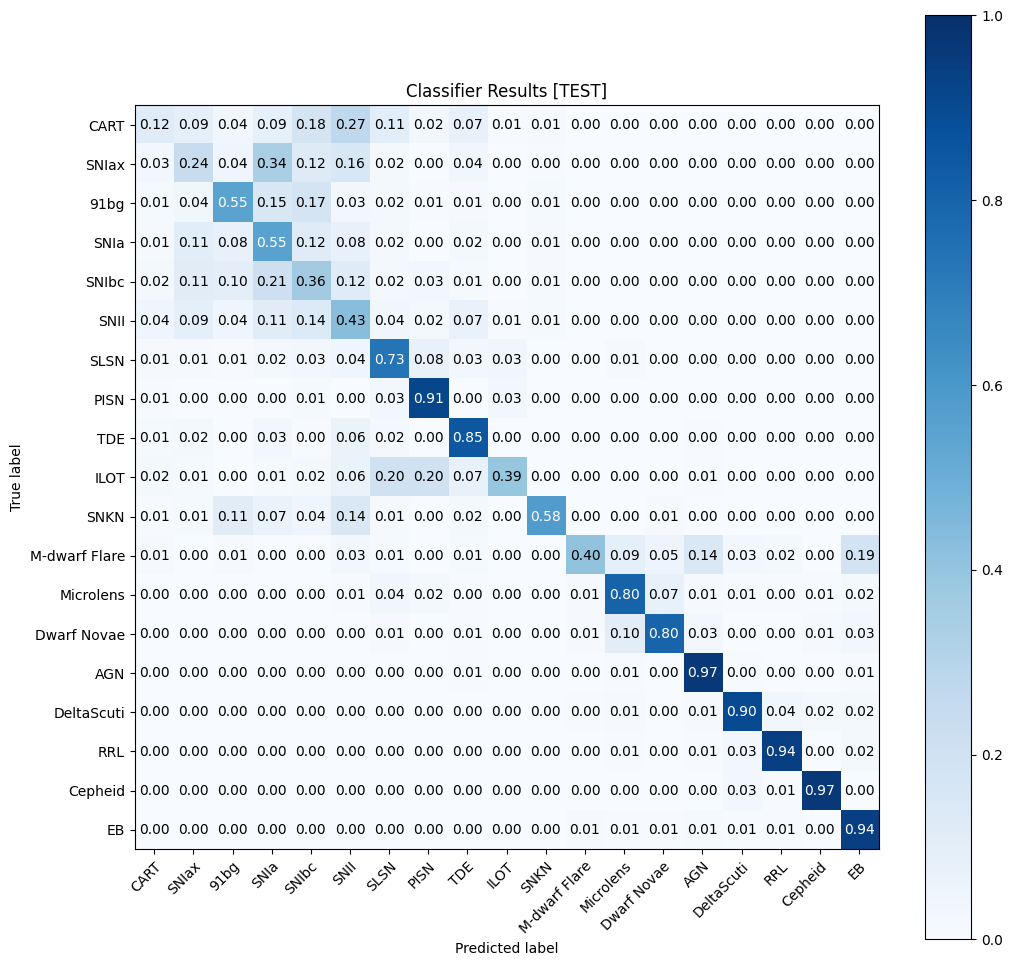

In [13]:
test.classification_report('test')

In [14]:
def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in data_dict_1.items():
        if key in DICT.keys():
            #print(key,value)
            f1_baseline.append(value['f1-score'])
    df_1 = pd.DataFrame({'group':DICT.keys(), 'values':f1_baseline })
    ordered_df_1 = df_1#.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)
    

    for key,value in data_dict_2.items():
        if key in DICT.keys():
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':DICT.keys(), 'values':f1_finetune})
    ordered_df_2 = df_2#.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison for Eval Time {eval_time} ", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(0,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )
    # Show the plot
    plt.show()
compare_models(data_dict_1,data_dict_2)

NameError: name 'data_dict_1' is not defined

In [ ]:
transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}
periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}

In [ ]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict_1.items():
    #print(class_key)
    if class_key in DICT.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))

print('per',np.mean(per_f1))


group eval:
trans 0.09137402124221418
stoch 0.3075233844676247
per 0.44516766236377314


In [ ]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict_2.items():
    #print(class_key)
    if class_key in DICT.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')    
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

group eval:
trans 0.09057053026767672
stoch 0.3213394733576514
per 0.46253493405430646


In [ ]:
adfadf

NameError: name 'adfadf' is not defined

In [ ]:
def early_as(path_1:str, before_time:int,supress_cm = False,supress_dict = False):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        #print(b1['time'].shape,b1['mask'].shape)
        #b1['data'][:,before_time:,:] = 0
        #b1['time'][:,before_time:,:] = 0
        #b1['mask'] = (b1['data'] !=0)
        mask = torch.ones_like(b1['mask'])
        #mask[before_time:,:] = 0 
        #b1['mask'] = b1['mask'] * mask
        lc_emb = model(**b1)  
        t = b1['labels']
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    if supress_dict == 0:
        print(classification)
    if supress_cm == 0:        
        from src.utils.plottinglib import elasticc_confusion_matrix
        out_metrics_balto = classification_report(
            target, results, target_names=list(DICT.keys()), output_dict=True
        )["macro avg"]
        template_balto = ""
        for key in out_metrics_balto.keys():
            template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
        fig, axes = plt.subplots(1, 1, figsize=(12, 12))
        elasticc_confusion_matrix(
            y_true=np.array(target).astype(int),
            y_pred=np.array(results).astype(int),
            classes= np.array(list(DICT.keys())),
            ax=axes,
            normalize=True,
            
            title=f" FClassifier Results [TEST] \n\n {template_balto}",
        )
        plt.show()
    
    return data_dict

In [ ]:
data_dict_1['macro avg']['f1-score']

0.285232638797718

In [ ]:
e_times = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,200]
macro_f1_eval_times = {'d1':[],'d2':[]}
for eval_time in e_times:
    data_dict_1 = early_as(path_1, before_time = eval_time,supress_cm=True,supress_dict=True)
    data_dict_2 = early_as(path_2, before_time = eval_time,supress_cm=True,supress_dict=True)
    macro_f1_eval_times['d1'].append(data_dict_1['macro avg']['f1-score'])
    macro_f1_eval_times['d2'].append(data_dict_2['macro avg']['f1-score'])
    compare_models(data_dict_1,data_dict_2,eval_time)

data_dict_1 = produce_report(path_1)
data_dict_2 = produce_report(path_2) 

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


 20%|█▉        | 39/197 [00:03<00:15, 10.22it/s]


KeyboardInterrupt: 

In [ ]:
import seaborn as sns

sns.lineplot(macro_f1_eval_times[::-1])
#plt.legend(['baseline','pretrained'])

plt.title('F1-score for ')
plt.xticks(list(range(len(e_times))),[str(time) for time in e_times])
plt.xlabel('Max Evaluated Time')
plt.ylabel('F1-score')
plt.grid('on')

KeyError: slice(None, None, -1)

modl is not sample dependent